# Import Libraries

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import random

from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.preprocessing import StandardScaler

SEED_VALUE = 42
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)

2024-03-16 19:43:32.650958: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-03-16 19:43:32.737894: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-16 19:43:32.737941: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-16 19:43:32.738984: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-16 19:43:32.746094: I tensorflow/core/platform/cpu_feature_guar

# Load Data

In [2]:
df = pd.read_csv("./concrete_data.csv")
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


# Explore Data (EDA)

In [3]:
df.shape

(1030, 9)

In [4]:
df.isna().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [5]:
df.duplicated().sum()

25

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.shape

(1005, 9)

# Preprocessing

## Split Data

In [8]:
x, y = df.drop(columns=['Strength'], axis=1), df['Strength']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=SEED_VALUE)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.4, random_state=SEED_VALUE)
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(703, 8) (703,)
(181, 8) (181,)
(121, 8) (121,)


## Create Normalization Layers

In [9]:
normalizer = tf.keras.layers.Normalization(axis=-1)

In [10]:
normalizer.adapt(np.array(x_train))

2024-03-16 19:43:36.002513: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-16 19:43:36.076441: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-16 19:43:36.076536: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-16 19:43:36.080034: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-16 19:43:36.080195: I external/local_xla/xla/stream_executor

For this model I will use a normalization layer that's adapted based on the x train features. I am using this approach to assume that all of the data that's going to be used that has similar features will not be normally distributed.

## Create Tensor Dataset

In [11]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(32)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(32)
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(32)

# Modelling

## Functional

In [12]:
inputs = tf.keras.Input(shape=(8,))
normalized = normalizer(inputs)
dense1 = Dense(13, activation='relu')(normalized)
dense2 = Dense(12, activation='relu')(dense1)
cat_layer = tf.keras.layers.Concatenate(axis=1)([dense1, dense2])
outputs = Dense(1)(cat_layer)


In [13]:
funcModel = Model(inputs=inputs, outputs=outputs)
funcModel.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 8)]                  0         []                            
                                                                                                  
 normalization (Normalizati  (None, 8)                    17        ['input_1[0][0]']             
 on)                                                                                              
                                                                                                  
 dense (Dense)               (None, 13)                   117       ['normalization[0][0]']       
                                                                                                  
 dense_1 (Dense)             (None, 12)                   168       ['dense[0][0]']           

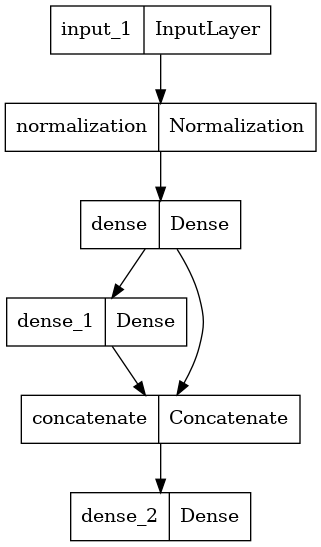

In [14]:
plot_model(funcModel)

In [15]:
funcModel.compile(loss=["mean_squared_error"], optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), metrics=["mean_absolute_error"])

In [16]:
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, mode='auto') # Stop training when `val_loss` is no longer improving in 3 epochs
]

history = funcModel.fit(train_ds, validation_data=val_ds, epochs=100, callbacks=my_callbacks)

Epoch 1/100


2024-03-16 19:43:42.133605: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f5e80dec0f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-03-16 19:43:42.133666: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2024-03-16 19:43:42.140216: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-03-16 19:43:42.159661: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
I0000 00:00:1710593022.275896   13750 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


22/22 [==============================] - 3s 17ms/step - loss: 1389.8668 - mean_absolute_error: 33.6538 - val_loss: 1297.8026 - val_mean_absolute_error: 31.3533
Epoch 2/100
22/22 [==============================] - 0s 9ms/step - loss: 845.9766 - mean_absolute_error: 24.3414 - val_loss: 507.8934 - val_mean_absolute_error: 17.5282
Epoch 3/100
22/22 [==============================] - 0s 10ms/step - loss: 289.5583 - mean_absolute_error: 13.5221 - val_loss: 274.4799 - val_mean_absolute_error: 12.7205
Epoch 4/100
22/22 [==============================] - 0s 12ms/step - loss: 192.5360 - mean_absolute_error: 11.0408 - val_loss: 220.3705 - val_mean_absolute_error: 11.7332
Epoch 5/100
22/22 [==============================] - 0s 11ms/step - loss: 160.2619 - mean_absolute_error: 10.3352 - val_loss: 193.9412 - val_mean_absolute_error: 11.1593
Epoch 6/100
22/22 [==============================] - 0s 11ms/step - loss: 144.9045 - mean_absolute_error: 9.7774 - val_loss: 180.7163 - val_mean_absolute_error: 

Callback function is used to stop the iteration when the loss doen't improve in 10 iteration.

In [21]:
funcModel.save('functional_model.h5')

/home/wbchn/miniconda3/envs/TensorFlow-DLN/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Model Evaluation

### R2 Score

In [18]:
## Calculating R2 score
from sklearn.metrics import r2_score

y_pred = funcModel.predict(x_test)
r2_score(y_test, y_pred)

4/4 [==============================] - 0s 5ms/step


0.813987049861859

### Train and Test Loss Graph

In [19]:
import matplotlib.pyplot as plt

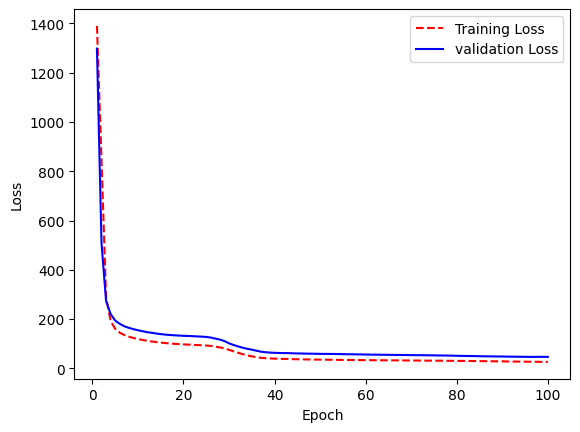

In [20]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

# Create count of the number of epochs
epoch_count = range(1, len(training_loss) + 1)

# Visualize loss history
plt.plot(epoch_count, training_loss, 'r--')
plt.plot(epoch_count, validation_loss, 'b-')
plt.legend(['Training Loss', 'validation Loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show();

From the graph above we can conclude that the model is a good fit because it has achieved near convergence. with the training loss and validation loss near equal. The model has achieved MSE of 26.0375 dan MAE or average error of 3.9371 on the training dataset to the real mean of the data and 46.6488 dan MAE of 4.8880 on the validation dataset to the real mean of the data. With the R2 score of the model is 0.8139 with the test dataset.